Comparing labelled datasets: the label-augmented cost
=====================================================

**When to use:** both sides are labelled datasets (features and classes) and the comparison should account for the
labels, as in the optimal transport dataset distance (OTDD).

**What you will see:** two datasets of 100,000 points in 10 classes, sampled from the same feature distribution,
where a growing share of the second dataset's labels is drawn at random; the distances between their labels, from
OT between classes; and the dataset distance with and without the label term. OT on the features alone stays near
zero; OTDD grows with the label noise.

Source: [plot_label_cost.py](plot_label_cost.py) · [Gallery](../README.md)

Reference figures and quoted results come from previous script runs. They are reading aids, not outputs from an execution of this notebook.

Install `pip install --upgrade 'flash-sinkhorn[notebooks]'`, clone this repository for the example files, and start `jupyter lab` from the checkout. Select its Python environment, then run the cells in order on an NVIDIA CUDA GPU. The setup cell finds the checkout from the repository root or this notebook's folder. The solver comes from the installed package. Running all cells prints fresh results and displays new figures; it also replaces the source's saved images. The scale examples retain the script's full problem sizes.

In [ ]:
# Find this checkout when Jupyter starts at its root or in a notebook folder.
import os
import sys
from pathlib import Path

for _candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (_candidate / 'examples/advanced/plot_label_cost.py').is_file() and (_candidate / "torch-ext/flash_sinkhorn").is_dir():
        _notebook_root = _candidate
        break
else:
    raise RuntimeError("Start Jupyter inside the flash-sinkhorn repository checkout.")

os.chdir(_notebook_root)
# Locate shared example helpers; import the solver from the installed package.
for _path in reversed([_notebook_root / "examples", _notebook_root]):
    if str(_path) in sys.path:
        sys.path.remove(str(_path))
    sys.path.insert(0, str(_path))
__file__ = str(_notebook_root / 'examples/advanced/plot_label_cost.py')

# Display the saved PNG/GIF files explicitly, including figures closed by the source.
import matplotlib
matplotlib.use("Agg")

Setup
-----

In [ ]:
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from flash_sinkhorn import SamplesLoss

sys.path.append(str(Path(__file__).resolve().parents[1]))  # the gallery's shared helpers
from _plotting import dense_size, images_dir, require_cuda, save, subsample, table, timed, to_numpy  # noqa: E402

device = require_cuda()
torch.manual_seed(0)
n, k = 100_000, 10
angles = 2 * math.pi * torch.arange(k, device=device) / k
centers = 2.0 * torch.stack([angles.cos(), angles.sin()], dim=1)


def dataset(noise):
    """n points in k Gaussian clusters, labelled by cluster, except a share ``noise`` of labels drawn at random."""
    cluster = torch.randint(0, k, (n,), device=device)
    points = centers[cluster] + 0.3 * torch.randn(n, 2, device=device)
    drawn = torch.rand(n, device=device) < noise
    return points, torch.where(drawn, torch.randint(0, k, (n,), device=device), cluster)


x, label_x = dataset(0.0)
print(dense_size(n, n))

Label distances
---------------
OTDD needs a distance between every two labels of either dataset: here the Sinkhorn divergence between the points
that carry them. The labels of y are numbered after those of x (k to 2k - 1), so W is 2k x 2k: its off-diagonal
blocks compare a class of x with a class of y, and its diagonal blocks, which the debiased dataset distance uses
to compare each dataset with itself, compare two classes of the same dataset.

In [ ]:
class_loss = SamplesLoss(blur=0.1, half_cost=True, debias=True, backend="symmetric", autotune=False)


def label_distances(y, label_y):
    groups = [x[label_x == i] for i in range(k)] + [y[label_y == j] for j in range(k)]
    W = torch.zeros(2 * k, 2 * k, device=device)
    for i in range(2 * k):
        for j in range(i + 1, 2 * k):
            W[i, j] = W[j, i] = class_loss(groups[i], groups[j])
    return W

The dataset distance
--------------------
The label-augmented cost is cost_scale (lambda_x |x - y|^2 + lambda_y W[label_x, label_y]). With ``lambda_y = 0``
it is OT on the features alone, which cannot see the labels; with ``lambda_y = 1`` every pair of points also pays
the distance between their labels. The last row renames the labels of y by a permutation and OTDD does not change:
it compares classes by their points, not by their names, so the two datasets need not share a label set.

In [ ]:
def distances(y, label_y):
    W = label_distances(y, label_y)
    values = []
    for lambda_y in (0.0, 1.0):
        otdd = SamplesLoss(blur=0.1, half_cost=True, debias=True, backend="symmetric", label_cost_matrix=W,
                           lambda_x=1.0, lambda_y=lambda_y, autotune=False)
        values.append(otdd(x, y, label_x=label_x, label_y=label_y + k).item())
    return W, values


y, label_y = dataset(0.0)
timed("label distances (190 class pairs) and both dataset distances", lambda: distances(y, label_y))
rows, shown = [], 0.5
for noise in (0.0, 0.1, 0.2, 0.5, 1.0):
    y, label_y = dataset(noise)
    W, (features, labelled) = distances(y, label_y)
    rows.append([f"{noise:g}", f"{features:.4f}", f"{labelled:.4f}"])
    if noise == shown:
        y_shown, label_y_shown, W_shown = y, label_y, W
renamed = torch.randperm(k, device=device)[label_y_shown]
_, (features, labelled) = distances(y_shown, renamed)
rows.append([f"{shown:g}, renamed", f"{features:.4f}", f"{labelled:.4f}"])
for row in rows:
    print(f"labels of y drawn at random: {row[0]}; OT on features {row[1]}; OTDD {row[2]}")

Figure
------

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11.0, 10.0))
keep = subsample(n, 20_000, device=device)
for ax, points, labels, title in ((axes[0, 0], x, label_x, "x: labels by cluster"),
                                  (axes[0, 1], y_shown, label_y_shown, f"y: {shown:.0%} of labels drawn at random")):
    ax.scatter(*to_numpy(points[keep]).T, c=to_numpy(labels[keep]), cmap="tab10", vmin=-0.5, vmax=9.5, s=1.0,
               edgecolors="none", rasterized=True)
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
image = axes[1, 0].imshow(to_numpy(W_shown), cmap="viridis")
axes[1, 0].axhline(k - 0.5, color="white", linewidth=1)
axes[1, 0].axvline(k - 0.5, color="white", linewidth=1)
axes[1, 0].set_xticks([k / 2 - 0.5, 1.5 * k - 0.5], ["labels of x", "labels of y"])
axes[1, 0].set_yticks([k / 2 - 0.5, 1.5 * k - 0.5], ["labels of x", "labels of y"], rotation=90, va="center")
axes[1, 0].set_title(f"label distances W, {shown:.0%} noise")
fig.colorbar(image, ax=axes[1, 0], fraction=0.046, pad=0.04)
table(axes[1, 1], ["labels of y drawn at random", "OT on features", "OTDD"], rows)
fig.tight_layout()
save(fig, images_dir(__file__), "label_cost")
plt.show()

In [ ]:
from IPython.display import Image as _NotebookImage, display as _notebook_display
_notebook_display(_NotebookImage(filename=str(_notebook_root / 'examples/advanced/images/label_cost.png')))
# Release figure managers so repeated runs do not accumulate open figures.
import matplotlib.pyplot as _notebook_plt
_notebook_plt.close("all")

**Reference figure from previous script runs.**

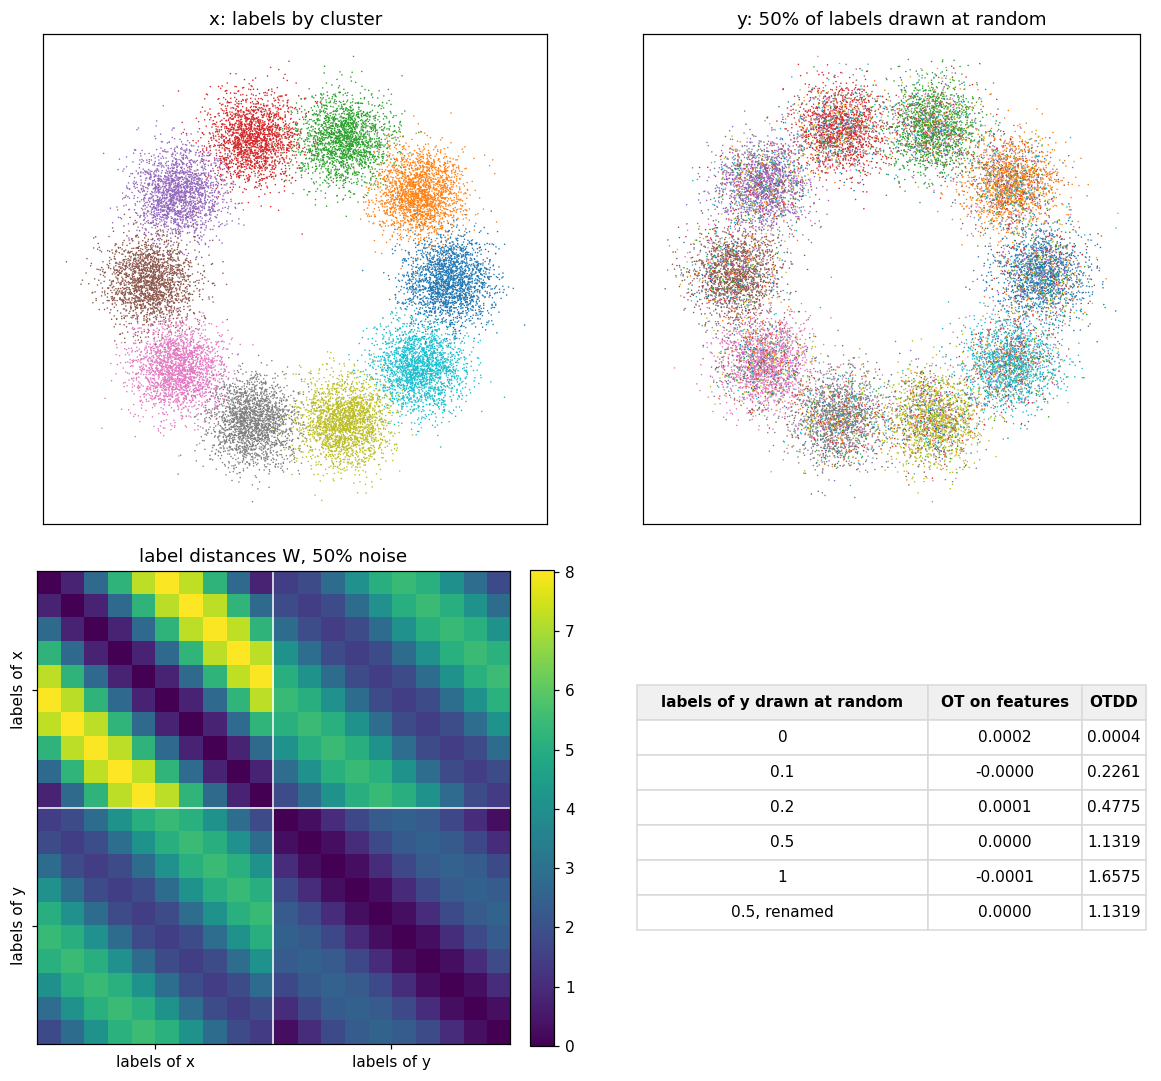